  2-D OPTIMISATION CONTOUR:  c_NaOH  ×  L_vol_flow
  [  1/180]  c_NaOH=0.050 M,  L=5.0 L/min  →  η=80.63%  STY=29220.0  util=6.556%
  [  2/180]  c_NaOH=0.050 M,  L=10.0 L/min  →  η=86.01%  STY=31170.2  util=3.499%
  [  3/180]  c_NaOH=0.050 M,  L=15.0 L/min  →  η=90.96%  STY=19979.8  util=2.468%
  [  4/180]  c_NaOH=0.050 M,  L=20.0 L/min  →  η=94.53%  STY=10839.1  util=1.925%
  [  5/180]  c_NaOH=0.050 M,  L=25.0 L/min  →  η=96.19%  STY=7533.2  util=1.567%
  [  6/180]  c_NaOH=0.050 M,  L=30.0 L/min  →  η=97.28%  STY=5378.9  util=1.321%
  [  7/180]  c_NaOH=0.050 M,  L=35.0 L/min  →  η=98.01%  STY=3934.6  util=1.141%
  [  8/180]  c_NaOH=0.050 M,  L=40.0 L/min  →  η=98.62%  STY=2558.0  util=1.004%
  [  9/180]  c_NaOH=0.050 M,  L=50.0 L/min  →  η=99.34%  STY=972.4  util=0.809%
  [ 10/180]  c_NaOH=0.050 M,  L=60.0 L/min  →  η=99.65%  STY=374.6  util=0.677%
  [ 11/180]  c_NaOH=0.050 M,  L=70.0 L/min  →  η=99.79%  STY=141.3  util=0.581%
  [ 12/180]  c_NaOH=0.050 M,  L=80.0 L/min  →  η=99.86%  S

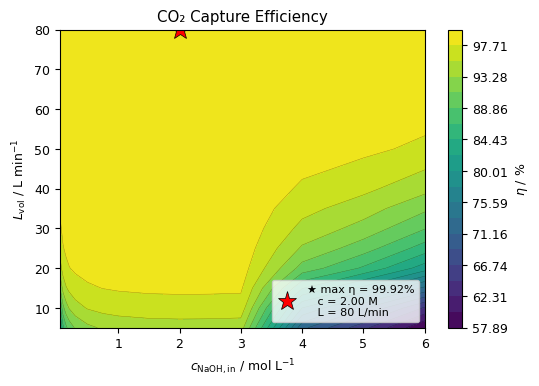

  → Saved contour_eta_cNaOH_Lvol


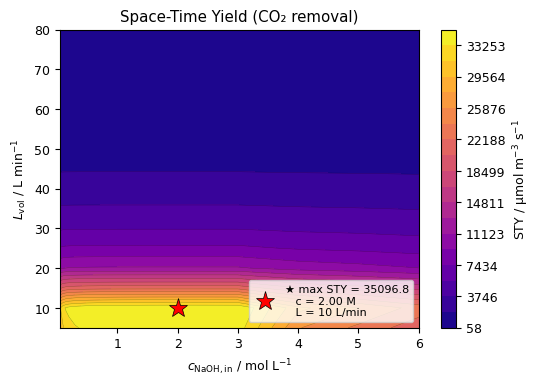

  → Saved contour_STY_cNaOH_Lvol


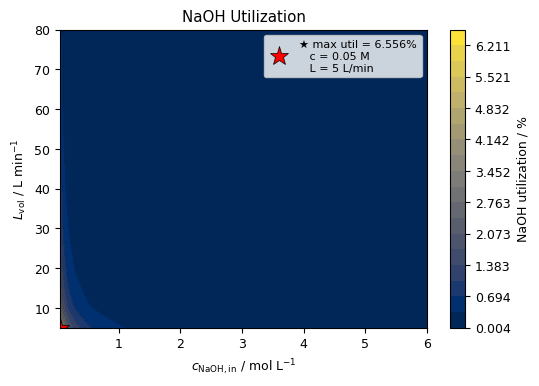

  → Saved contour_util_cNaOH_Lvol

  NELDER-MEAD OPTIMISATION — Maximise STY w.r.t. c_NaOH_in
    eval #  1: c=2.0000 M  η=99.660%  STY=2585.04
    eval #  2: c=2.1000 M  η=99.661%  STY=2585.04
    eval #  3: c=2.2000 M  η=99.660%  STY=2585.04
    eval #  4: c=2.0750 M  η=99.661%  STY=2585.04
    eval #  5: c=2.1250 M  η=99.661%  STY=2585.04
    eval #  6: c=2.0938 M  η=99.661%  STY=2585.04

  ★ Nelder-Mead result:
    Optimal c_NaOH_in = 2.0938 mol/L
    η                 = 99.661 %
    STY               = 2585.04 µmol/m³/s
    NaOH util.        = 0.0242 %
    Converged         = True
    Func. evals       = 6
    Optimizer success = True
    Message           = Optimization terminated successfully.

  NELDER-MEAD — Max NaOH utilization  (constraint: η ≥ 95%)
    eval #  1: c=0.5000 M  η=99.57%  util=0.1014%  obj=-0.1014
    eval #  2: c=0.5250 M  η=99.57%  util=0.0966%  obj=-0.0966
    eval #  3: c=0.4750 M  η=99.56%  util=0.1067%  obj=-0.1067
    eval #  4: c=0.4250 M  η=99.55%  uti

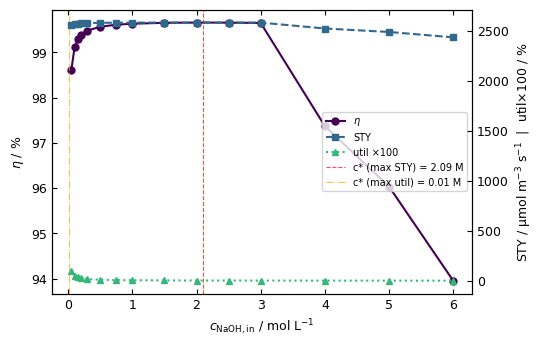

  → Saved optimization_summary_1D

  OPTIMISATION COMPLETE


In [ ]:
"""
=============================================================================
 Absorber Column Optimization — NaOH Concentration
 Contour plot: c_NaOH_in vs L_vol_flow  →  η, STY, NaOH utilization
=============================================================================
"""

import os
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Suppress verbose output during optimization sweeps
import io
import sys

# ── Import the Absorber class ──
from absorber import Absorber

# ── Output directories ──
optimization_dir = 'model_results/optimization/'
os.makedirs(optimization_dir, exist_ok=True)


# =============================================================================
#  Helper: run one absorber case silently
# =============================================================================
def run_absorber_silent(c_NaOH_in, L_vol_flow, **kwargs):
    """
    Build, solve, and extract KPIs from an Absorber instance.
    All print output is suppressed.
    Returns dict with KPIs or None on failure.
    """
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ab = Absorber(
                c_NaOH_in=c_NaOH_in,
                L_vol_flow=L_vol_flow,
                **kwargs,
            )
            ab.solve_column()
            eta  = ab.capture_efficiency()      # %
            sty  = ab.removal_rate()            # mol/m³/s
            util = ab.NaOH_utilization()        # fraction
            converged = ab.bvp_converged
    except Exception:
        sys.stdout = old_stdout
        return None
    finally:
        sys.stdout = old_stdout

    return {
        "eta":       eta,
        "sty":       sty * 1e6,        # µmol/m³/s
        "util":      util * 100.0,     # %
        "converged": converged,
        "c_NaOH":    c_NaOH_in,
        "L_vol":     L_vol_flow,
    }


# =============================================================================
#  1.  2-D CONTOUR SWEEP:  c_NaOH  ×  L_vol_flow
# =============================================================================
print("=" * 62)
print("  2-D OPTIMISATION CONTOUR:  c_NaOH  ×  L_vol_flow")
print("=" * 62)

# ── Grid definition ──
# NaOH: 0.05 – 6 M  (log-spaced for better low-end resolution)
c_NaOH_vals = np.array([
    0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75,
    1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0,
])

# Liquid flow rate: 5 – 80 L/min
L_vol_vals = np.array([
    5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,
    40.0, 50.0, 60.0, 70.0, 80.0,
])

n_c = len(c_NaOH_vals)
n_L = len(L_vol_vals)

# ── Allocate result matrices ──
ETA  = np.full((n_c, n_L), np.nan)
STY  = np.full((n_c, n_L), np.nan)
UTIL = np.full((n_c, n_L), np.nan)
CONV = np.full((n_c, n_L), False)

total = n_c * n_L
count = 0

for i, c in enumerate(c_NaOH_vals):
    for j, L in enumerate(L_vol_vals):
        count += 1
        print(f"  [{count:3d}/{total}]  c_NaOH={c:.3f} M,  L={L:.1f} L/min",
              end="  →  ", flush=True)

        res = run_absorber_silent(c, L)
        if res is not None and res["converged"]:
            ETA[i, j]  = res["eta"]
            STY[i, j]  = res["sty"]
            UTIL[i, j] = res["util"]
            CONV[i, j] = True
            print(f"η={res['eta']:.2f}%  STY={res['sty']:.1f}  "
                  f"util={res['util']:.3f}%")
        else:
            tag = "FAILED" if res is None else "NO CONV"
            print(tag)

# Save raw data
np.savez(
    os.path.join(optimization_dir, "contour_data.npz"),
    c_NaOH_vals=c_NaOH_vals,
    L_vol_vals=L_vol_vals,
    ETA=ETA, STY=STY, UTIL=UTIL, CONV=CONV,
)

# =============================================================================
#  2.  CONTOUR PLOTS
# =============================================================================
cm = 1 / 2.54
plt.rcParams.update({"font.size": 9})
C_grid, L_grid = np.meshgrid(c_NaOH_vals, L_vol_vals, indexing="ij")

# ── Plot 1: Capture efficiency η ──
fig, ax = plt.subplots(1, 1, figsize=(14 * cm, 10 * cm))
levels_eta = np.linspace(
    np.nanmin(ETA[CONV]) if np.any(CONV) else 80,
    np.nanmax(ETA[CONV]) if np.any(CONV) else 100,
    20,
)
cs = ax.contourf(C_grid, L_grid, ETA, levels=levels_eta, cmap="viridis")
ax.contour(C_grid, L_grid, ETA, levels=levels_eta, colors="k",
           linewidths=0.3, alpha=0.4)
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label(r"$\eta$ / %")

# Mark the optimum
if np.any(CONV):
    idx_best = np.unravel_index(np.nanargmax(ETA), ETA.shape)
    ax.plot(c_NaOH_vals[idx_best[0]], L_vol_vals[idx_best[1]],
            "r*", markersize=14, markeredgecolor="k", markeredgewidth=0.5,
            label=(f"★ max η = {ETA[idx_best]:.2f}%\n"
                   f"   c = {c_NaOH_vals[idx_best[0]]:.2f} M\n"
                   f"   L = {L_vol_vals[idx_best[1]]:.0f} L/min"))
    ax.legend(loc="lower right", frameon=True, fontsize=8)

ax.set_xlabel(r"$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$")
ax.set_ylabel(r"$L_{\mathrm{vol}}$ / L min$^{-1}$")
ax.set_title("CO₂ Capture Efficiency")
plt.tight_layout()
plt.savefig(os.path.join(optimization_dir, "contour_eta_cNaOH_Lvol.svg"))
plt.savefig(os.path.join(optimization_dir, "contour_eta_cNaOH_Lvol.png"),
            dpi=200)
plt.show()
print("  → Saved contour_eta_cNaOH_Lvol")

# ── Plot 2: Space-Time Yield ──
fig, ax = plt.subplots(1, 1, figsize=(14 * cm, 10 * cm))
levels_sty = np.linspace(
    np.nanmin(STY[CONV]) if np.any(CONV) else 0,
    np.nanmax(STY[CONV]) if np.any(CONV) else 3000,
    20,
)
cs = ax.contourf(C_grid, L_grid, STY, levels=levels_sty, cmap="plasma")
ax.contour(C_grid, L_grid, STY, levels=levels_sty, colors="k",
           linewidths=0.3, alpha=0.4)
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label(r"STY / µmol m$^{-3}$ s$^{-1}$")

if np.any(CONV):
    idx_best_sty = np.unravel_index(np.nanargmax(STY), STY.shape)
    ax.plot(c_NaOH_vals[idx_best_sty[0]], L_vol_vals[idx_best_sty[1]],
            "r*", markersize=14, markeredgecolor="k", markeredgewidth=0.5,
            label=(f"★ max STY = {STY[idx_best_sty]:.1f}\n"
                   f"   c = {c_NaOH_vals[idx_best_sty[0]]:.2f} M\n"
                   f"   L = {L_vol_vals[idx_best_sty[1]]:.0f} L/min"))
    ax.legend(loc="lower right", frameon=True, fontsize=8)

ax.set_xlabel(r"$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$")
ax.set_ylabel(r"$L_{\mathrm{vol}}$ / L min$^{-1}$")
ax.set_title("Space-Time Yield (CO₂ removal)")
plt.tight_layout()
plt.savefig(os.path.join(optimization_dir, "contour_STY_cNaOH_Lvol.svg"))
plt.savefig(os.path.join(optimization_dir, "contour_STY_cNaOH_Lvol.png"),
            dpi=200)
plt.show()
print("  → Saved contour_STY_cNaOH_Lvol")

# ── Plot 3: NaOH Utilization ──
fig, ax = plt.subplots(1, 1, figsize=(14 * cm, 10 * cm))
UTIL_plot = UTIL.copy()
UTIL_plot[~CONV] = np.nan
levels_util = np.linspace(
    np.nanmin(UTIL_plot) if np.any(CONV) else 0,
    min(np.nanmax(UTIL_plot), 10) if np.any(CONV) else 1,
    20,
)
cs = ax.contourf(C_grid, L_grid, UTIL_plot, levels=levels_util,
                 cmap="cividis")
ax.contour(C_grid, L_grid, UTIL_plot, levels=levels_util, colors="k",
           linewidths=0.3, alpha=0.4)
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label("NaOH utilization / %")

if np.any(CONV):
    idx_best_util = np.unravel_index(np.nanargmax(UTIL_plot), UTIL.shape)
    ax.plot(c_NaOH_vals[idx_best_util[0]], L_vol_vals[idx_best_util[1]],
            "r*", markersize=14, markeredgecolor="k", markeredgewidth=0.5,
            label=(f"★ max util = {UTIL[idx_best_util]:.3f}%\n"
                   f"   c = {c_NaOH_vals[idx_best_util[0]]:.2f} M\n"
                   f"   L = {L_vol_vals[idx_best_util[1]]:.0f} L/min"))
    ax.legend(loc="upper right", frameon=True, fontsize=8)

ax.set_xlabel(r"$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$")
ax.set_ylabel(r"$L_{\mathrm{vol}}$ / L min$^{-1}$")
ax.set_title("NaOH Utilization")
plt.tight_layout()
plt.savefig(os.path.join(optimization_dir, "contour_util_cNaOH_Lvol.svg"))
plt.savefig(os.path.join(optimization_dir, "contour_util_cNaOH_Lvol.png"),
            dpi=200)
plt.show()
print("  → Saved contour_util_cNaOH_Lvol")


# =============================================================================
#  3.  NELDER-MEAD OPTIMISATION — Maximize STY (single parameter: c_NaOH)
# =============================================================================
print("\n" + "=" * 62)
print("  NELDER-MEAD OPTIMISATION — Maximise STY w.r.t. c_NaOH_in")
print("=" * 62)

eval_count = [0]

def objective_max_sty(x):
    """Negative STY (to minimise) as a function of c_NaOH_in."""
    c = float(x[0])
    if c < 0.01 or c > 10.0:
        return 1e6  # penalty for out-of-bounds
    eval_count[0] += 1
    res = run_absorber_silent(c, L_vol_flow=40.0)
    if res is None or not res["converged"]:
        print(f"    eval #{eval_count[0]:3d}: c={c:.4f} M  → FAILED")
        return 1e6
    print(f"    eval #{eval_count[0]:3d}: c={c:.4f} M  "
          f"η={res['eta']:.3f}%  STY={res['sty']:.2f}")
    return -res["sty"]   # negative because we minimise


x0 = np.array([2.0])  # initial guess
result_nm = minimize(
    objective_max_sty,
    x0,
    method="Nelder-Mead",
    options={
        "xatol": 0.01,
        "fatol": 0.1,
        "maxiter": 50,
        "adaptive": True,
    },
)

c_opt = float(result_nm.x[0])
res_opt = run_absorber_silent(c_opt, L_vol_flow=40.0)

print(f"\n  ★ Nelder-Mead result:")
print(f"    Optimal c_NaOH_in = {c_opt:.4f} mol/L")
if res_opt is not None:
    print(f"    η                 = {res_opt['eta']:.3f} %")
    print(f"    STY               = {res_opt['sty']:.2f} µmol/m³/s")
    print(f"    NaOH util.        = {res_opt['util']:.4f} %")
    print(f"    Converged         = {res_opt['converged']}")
print(f"    Func. evals       = {result_nm.nfev}")
print(f"    Optimizer success = {result_nm.success}")
print(f"    Message           = {result_nm.message}")


# =============================================================================
#  4.  NELDER-MEAD OPTIMISATION — Maximize NaOH utilization at ≥95% η
# =============================================================================
print("\n" + "=" * 62)
print("  NELDER-MEAD — Max NaOH utilization  (constraint: η ≥ 95%)")
print("=" * 62)

eval_count2 = [0]

def objective_max_util(x):
    """
    Negative NaOH utilization (to minimise).
    Penalty if η < 95%.
    """
    c = float(x[0])
    if c < 0.01 or c > 10.0:
        return 1e6
    eval_count2[0] += 1
    res = run_absorber_silent(c, L_vol_flow=40.0)
    if res is None or not res["converged"]:
        print(f"    eval #{eval_count2[0]:3d}: c={c:.4f} M  → FAILED")
        return 1e6

    penalty = 0.0
    if res["eta"] < 95.0:
        penalty = 100.0 * (95.0 - res["eta"]) ** 2

    obj = -res["util"] + penalty
    print(f"    eval #{eval_count2[0]:3d}: c={c:.4f} M  "
          f"η={res['eta']:.2f}%  util={res['util']:.4f}%  obj={obj:.4f}")
    return obj


x0_util = np.array([0.5])
result_util = minimize(
    objective_max_util,
    x0_util,
    method="Nelder-Mead",
    options={
        "xatol": 0.005,
        "fatol": 0.001,
        "maxiter": 60,
        "adaptive": True,
    },
)

c_opt_util = float(result_util.x[0])
res_opt_util = run_absorber_silent(c_opt_util, L_vol_flow=40.0)

print(f"\n  ★ Nelder-Mead result (max utilization, η ≥ 95%):")
print(f"    Optimal c_NaOH_in = {c_opt_util:.4f} mol/L")
if res_opt_util is not None:
    print(f"    η                 = {res_opt_util['eta']:.3f} %")
    print(f"    STY               = {res_opt_util['sty']:.2f} µmol/m³/s")
    print(f"    NaOH util.        = {res_opt_util['util']:.4f} %")
    print(f"    Converged         = {res_opt_util['converged']}")
print(f"    Func. evals       = {result_util.nfev}")
print(f"    Optimizer success = {result_util.success}")


# =============================================================================
#  5.  SUMMARY COMPARISON PLOT
# =============================================================================
print("\n" + "=" * 62)
print("  GENERATING SUMMARY 1-D PLOT")
print("=" * 62)

# Use the L=40 row from the contour data
j_40 = np.argmin(np.abs(L_vol_vals - 40.0))
eta_slice = ETA[:, j_40]
sty_slice = STY[:, j_40]
util_slice = UTIL[:, j_40]
valid = CONV[:, j_40]

cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 4))

fig, ax1 = plt.subplots(1, 1, figsize=(14 * cm, 9 * cm))
ax2 = ax1.twinx()

p1, = ax1.plot(c_NaOH_vals[valid], eta_slice[valid], "o-",
               color=colors[0], label=r"$\eta$", markersize=5)
p2, = ax2.plot(c_NaOH_vals[valid], sty_slice[valid], "s--",
               color=colors[1], label="STY", markersize=5)
p3, = ax2.plot(c_NaOH_vals[valid], util_slice[valid] * 100, "^:",
               color=colors[2], label="util ×100", markersize=5)

# Mark optima
if res_opt is not None:
    ax1.axvline(c_opt, color="red", ls="--", lw=0.8, alpha=0.7,
                label=f"c* (max STY) = {c_opt:.2f} M")
if res_opt_util is not None:
    ax1.axvline(c_opt_util, color="orange", ls="-.", lw=0.8, alpha=0.7,
                label=f"c* (max util) = {c_opt_util:.2f} M")

ax1.set_xlabel(r"$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$")
ax1.set_ylabel(r"$\eta$ / %")
ax2.set_ylabel(r"STY / µmol m$^{-3}$ s$^{-1}$  |  util×100 / %")

lines = [p1, p2, p3]
if res_opt is not None:
    lines.append(ax1.get_lines()[-2])
if res_opt_util is not None:
    lines.append(ax1.get_lines()[-1])
ax1.legend(lines, [l.get_label() for l in lines],
           loc="center right", frameon=True, fontsize=7)

ax1.tick_params(direction="in", top=True)
ax2.tick_params(direction="in")
plt.tight_layout()
plt.savefig(os.path.join(optimization_dir, "optimization_summary_1D.svg"))
plt.savefig(os.path.join(optimization_dir, "optimization_summary_1D.png"),
            dpi=200)
plt.show()
print("  → Saved optimization_summary_1D")

print("\n" + "=" * 62)
print("  OPTIMISATION COMPLETE")
print("=" * 62)